<a href="https://colab.research.google.com/github/321222/Adventure_game/blob/main/Marketing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 28 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   2240 non-null   int64  
 1   Year_Birth           2240 non-null   int64  
 2   Education            2240 non-null   object 
 3   Marital_Status       2240 non-null   object 
 4   Income               2216 non-null   float64
 5   Kidhome              2240 non-null   int64  
 6   Teenhome             2240 non-null   int64  
 7   Dt_Customer          2240 non-null   object 
 8   Recency              2240 non-null   int64  
 9   MntWines             2240 non-null   int64  
 10  MntFruits            2240 non-null   int64  
 11  MntMeatProducts      2240 non-null   int64  
 12  MntFishProducts      2240 non-null   int64  
 13  MntSweetProducts     2240 non-null   int64  
 14  MntGoldProds         2240 non-null   int64  
 15  NumDealsPurchases    2240 non-null   i

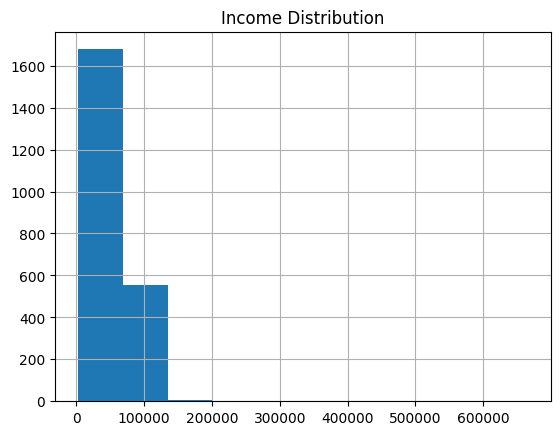

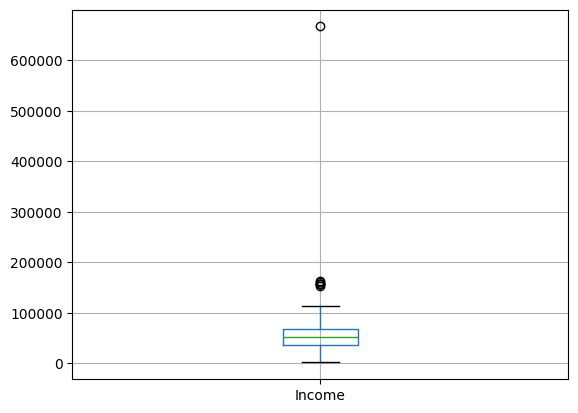

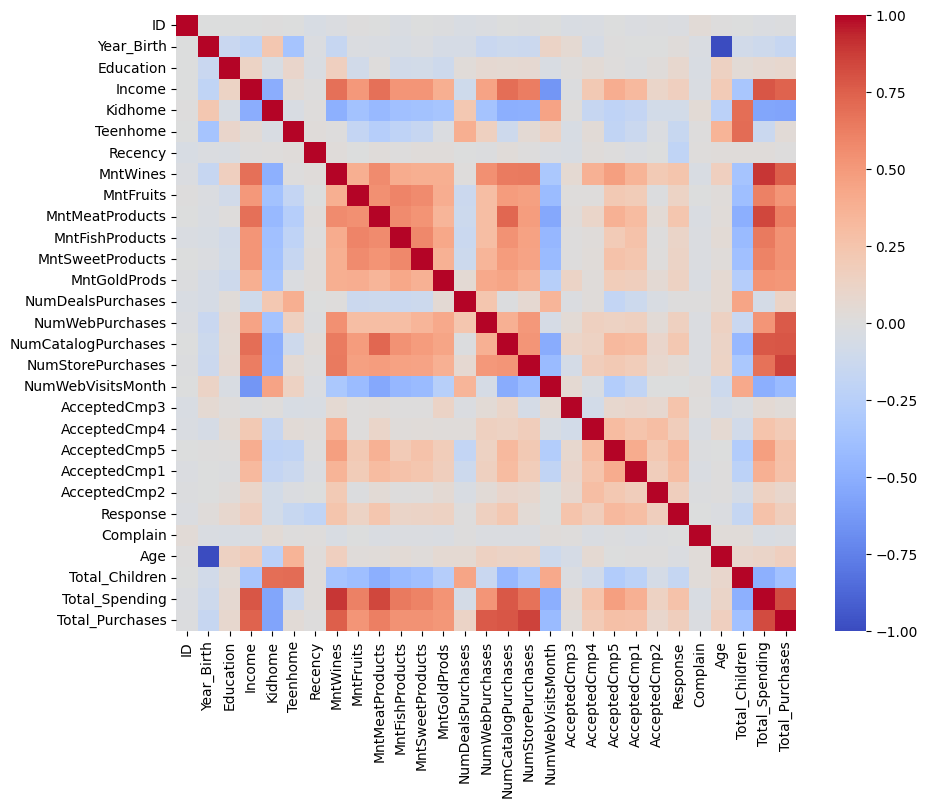

,count
Education,
1,14
2,6
3,1


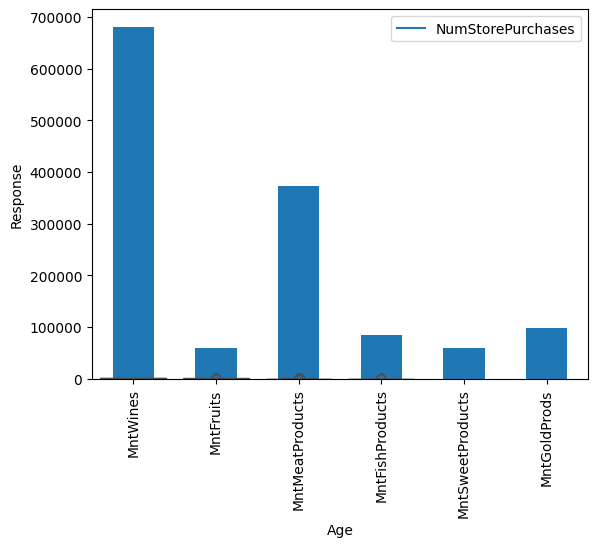

In [11]:
import pandas as pd
import numpy as np

df = pd.read_csv("marketing_data.csv")

df.columns = df.columns.str.strip() # Strip whitespace from column names

df['Income'] = df['Income'].replace('[$,]', '', regex=True).astype(float) # Clean and convert 'Income' to numeric

df.info()
df.head()
df.describe()
df['Dt_Customer'] = pd.to_datetime(df['Dt_Customer'], format='%m/%d/%y', errors='coerce') # Specify format to avoid warning
df['Education'] = df['Education'].replace({
    '2n Cycle': 'Master',
    'Graduation': 'Graduate',
    'PhD': 'Doctorate'
}) # Removed inplace=True to avoid FutureWarning

df['Marital_Status'] = df['Marital_Status'].replace({
    'Alone': 'Single',
    'YOLO': 'Single',
    'Absurd': 'Single'
}) # Removed inplace=True to avoid FutureWarning
df['Income'] = df.groupby(['Education', 'Marital_Status'])['Income'].transform(lambda x: x.fillna(x.mean()))
df['Age'] = 2026 - df['Year_Birth']
df['Total_Children'] = df['Kidhome'] + df['Teenhome']
df['Total_Spending'] = (
    df['MntWines'] + df['MntFruits'] + df['MntMeatProducts'] +
    df['MntFishProducts'] + df['MntSweetProducts'] + df['MntGoldProds']
)
df['Total_Purchases'] = (
    df['NumWebPurchases'] +
    df['NumCatalogPurchases'] +
    df['NumStorePurchases']
)
import matplotlib.pyplot as plt

df['Income'].hist()
plt.title("Income Distribution")
plt.show()

df.boxplot(column=['Income'])
plt.show()

df = df[df['Income'] < 600000]
education_order = {'Basic':0, 'Graduate':1, 'Master':2, 'Doctorate':3}
df['Education'] = df['Education'].map(education_order)
df = pd.get_dummies(df, columns=['Marital_Status'], drop_first=True)
import seaborn as sns

plt.figure(figsize=(10,8))
sns.heatmap(df.select_dtypes(include=np.number).corr(), cmap='coolwarm') # Filter for numeric types for correlation
plt.show()
df.groupby('Age')['NumStorePurchases'].mean().plot()
df.groupby('Total_Children')['NumWebPurchases'].mean()
df[['NumWebPurchases', 'NumStorePurchases']].corr()
df.groupby('Country')['Total_Purchases'].mean()
products = df[['MntWines','MntFruits','MntMeatProducts',
               'MntFishProducts','MntSweetProducts','MntGoldProds']].sum()

products.plot(kind='bar')
sns.scatterplot(x=df['Age'], y=df['Response'])
df.groupby('Country')['Response'].sum()
sns.boxplot(x=df['Total_Children'], y=df['Total_Spending'])
df[df['Complain']==1]['Education'].value_counts()